# EDA - Sales


## Importamos desde Google Cloud

In [1]:
from google.cloud import storage

# Configuración
PROJECT_ID = "inventarioproject-471611"
BUCKET_NAME = "proyecto_inventario_bucket"

# Conectar a Google Cloud Storage
client_storage = storage.Client(project=PROJECT_ID)

try:
    bucket = client_storage.bucket(BUCKET_NAME)
    print(f"✅ Conexión exitosa al bucket: {BUCKET_NAME}")

    # Listar archivos
    blobs = list(bucket.list_blobs())
    if not blobs:
        print("⚠️ El bucket está vacío.")
    else:
        print("📂 Archivos encontrados en el bucket:")
        for blob in blobs:
            print("-", blob.name)
except Exception as e:
    print("❌ Error al conectar o listar archivos:")
    print(e)

✅ Conexión exitosa al bucket: proyecto_inventario_bucket
📂 Archivos encontrados en el bucket:
- EndInvFINAL12312016.csv
- InvoicePurchases12312016.csv
- PurchasesFINAL12312016.csv
- SalesFINAL12312016.csv


In [2]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:\Users\Usuario\AppData\Roaming\gcloud\application_default_credentials.json"

In [3]:
import sys
print(sys.executable)

c:\Users\Usuario\OneDrive\Escritorio\InventarioProject\PF-Inventory\venv_inventario\Scripts\python.exe


In [4]:
# ==========================================
# ETL seguro: Verificar bucket, descargar CSV
# ==========================================

import os
from google.cloud import storage
import pandas as pd

# ---- Configuración ----
PROJECT_ID = "inventarioproject-471611"           # Tu proyecto de GCP
BUCKET_NAME = "proyecto_inventario_bucket"       # Tu bucket
CSV_FILE_NAME = "SalesFINAL12312016.csv"     # Archivo que querés procesar
LOCAL_FILE = "SalesFINAL12312016.csv"        # Nombre temporal local

# ---- Configurar credenciales ----
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:\Users\Usuario\AppData\Roaming\gcloud\application_default_credentials.json"

# ---- Conectar con GCS ----
try:
    client_storage = storage.Client(project=PROJECT_ID)
    bucket = client_storage.get_bucket(BUCKET_NAME)
    print(f"✅ Conexión exitosa al bucket: {BUCKET_NAME}")
except Exception as e:
    print("❌ No se pudo conectar al bucket. Error:")
    print(e)

# ---- Listar archivos del bucket ----
try:
    blobs = list(bucket.list_blobs())
    if len(blobs) == 0:
        print("⚠️ El bucket está vacío")
    else:
        print("Archivos encontrados en el bucket:")
        for b in blobs:
            print("-", b.name)
except Exception as e:
    print("❌ No se pudieron listar los archivos. Error:")
    print(e)

# ---- Descargar CSV solo si existe ----
if CSV_FILE_NAME in [b.name for b in blobs]:
    print(f"📥 Descargando archivo: {CSV_FILE_NAME}...")
    blob = bucket.blob(CSV_FILE_NAME)
    blob.download_to_filename(LOCAL_FILE)
    print("✅ Descarga completada")
else:
    print(f"❌ No se encontró el archivo {CSV_FILE_NAME} en el bucket")

# ---- Leer CSV ----
try:
    df = pd.read_csv(LOCAL_FILE)
    print(f"✅ CSV cargado. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
except Exception as e:
    print("❌ Error al leer CSV:")
    print(e)

# ---- Mostrar primeras filas ----
print("Primeras 5 filas del DataFrame:")
print(df.head())

✅ Conexión exitosa al bucket: proyecto_inventario_bucket
Archivos encontrados en el bucket:
- EndInvFINAL12312016.csv
- InvoicePurchases12312016.csv
- PurchasesFINAL12312016.csv
- SalesFINAL12312016.csv
📥 Descargando archivo: SalesFINAL12312016.csv...
✅ Descarga completada
✅ CSV cargado. Filas: 1048575, Columnas: 14
Primeras 5 filas del DataFrame:
           InventoryId  Store  Brand                 Description        Size  \
0  1_HARDERSFIELD_1004      1   1004  Jim Beam w/2 Rocks Glasses       750mL   
1  1_HARDERSFIELD_1004      1   1004  Jim Beam w/2 Rocks Glasses       750mL   
2  1_HARDERSFIELD_1004      1   1004  Jim Beam w/2 Rocks Glasses       750mL   
3  1_HARDERSFIELD_1004      1   1004  Jim Beam w/2 Rocks Glasses       750mL   
4  1_HARDERSFIELD_1005      1   1005     Maker's Mark Combo Pack  375mL 2 Pk   

   SalesQuantity  SalesDollars  SalesPrice SalesDate  Volume  Classification  \
0              1         16.49       16.49  1/1/2016     750               1   
1        

## EDA paso 1: Dimensiones y estructura general

In [5]:
print("Dimensiones del dataset:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print("-" * 40)

print("Información general de las columnas:")
df.info()

Dimensiones del dataset:
Filas: 1048575
Columnas: 14
----------------------------------------
Información general de las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 14 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   InventoryId     1048575 non-null  object 
 1   Store           1048575 non-null  int64  
 2   Brand           1048575 non-null  int64  
 3   Description     1048575 non-null  object 
 4   Size            1048575 non-null  object 
 5   SalesQuantity   1048575 non-null  int64  
 6   SalesDollars    1048575 non-null  float64
 7   SalesPrice      1048575 non-null  float64
 8   SalesDate       1048575 non-null  object 
 9   Volume          1048575 non-null  int64  
 10  Classification  1048575 non-null  int64  
 11  ExciseTax       1048575 non-null  float64
 12  VendorNo        1048575 non-null  int64  
 13  VendorName      1048575 non-null  object 
dtyp

## EDA Paso 2: Vista preliminar de los datos

* Mostrar primeras filas .head( )

* Mostrar últimas filas .tail( )

* Revisar nombres de columnas df.columns

In [6]:
df.head(5)

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,1/1/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,1/2/2016,750,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,1/3/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,1/8/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,1/9/2016,375,1,0.79,12546,JIM BEAM BRANDS COMPANY


In [7]:
df.tail()

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
1048570,19_WINTERVALE_39384,19,39384,F Coppola Diamond Pnt Nr,750mL,4,51.80,12.95,2/12/2016,750,2,0.45,2000,SOUTHERN WINE & SPIRITS NE
1048571,19_WINTERVALE_39384,19,39384,F Coppola Diamond Pnt Nr,750mL,8,103.60,12.95,2/13/2016,750,2,0.90,2000,SOUTHERN WINE & SPIRITS NE
1048572,19_WINTERVALE_39384,19,39384,F Coppola Diamond Pnt Nr,750mL,1,12.95,12.95,2/19/2016,750,2,0.11,2000,SOUTHERN WINE & SPIRITS NE
1048573,19_WINTERVALE_39384,19,39384,F Coppola Diamond Pnt Nr,750mL,3,38.85,12.95,2/22/2016,750,2,0.34,2000,SOUTHERN WINE & SPIRITS NE
1048574,19_WINTERVALE_39384,19,39384,F Coppola Diamond Pnt Nr,750mL,2,25.90,12.95,2/24/2016,750,2,0.22,2000,SOUTHERN WINE & SPIRITS NE


In [8]:
df.columns

Index(['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'SalesQuantity',
       'SalesDollars', 'SalesPrice', 'SalesDate', 'Volume', 'Classification',
       'ExciseTax', 'VendorNo', 'VendorName'],
      dtype='object')

## EDA Paso 3: Valores faltantes y duplicados

* Contar valores nulos df.isnull().sum()

* Revisar filas duplicadas df.duplicated().sum()

In [9]:
df.isnull().sum()

InventoryId       0
Store             0
Brand             0
Description       0
Size              0
SalesQuantity     0
SalesDollars      0
SalesPrice        0
SalesDate         0
Volume            0
Classification    0
ExciseTax         0
VendorNo          0
VendorName        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## EDA Paso 4: Estadísticas descriptivas

* Resumen numérico (df.describe()  media, std, min, max, percentiles).

* Revisar distribuciones de columnas clave.

In [11]:
df.describe()

,Store,Brand,SalesQuantity,SalesDollars,SalesPrice,Volume,Classification,ExciseTax,VendorNo
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,4.008063e+01,1.216959e+04,2.337619e+00,3.160420e+01,1.543162e+01,9.500280e+02,1.416550e+00,1.326847e+00,6.995043e+03
std,2.435739e+01,1.241921e+04,3.511492e+00,6.570249e+01,1.404967e+01,7.142708e+02,4.929872e-01,3.407898e+00,8.426736e+03
min,1.000000e+00,5.800000e+01,1.000000e+00,4.900000e-01,4.900000e-01,5.000000e+01,1.000000e+00,1.000000e-02,2.000000e+00
25%,1.500000e+01,3.680000e+03,1.000000e+00,1.099000e+01,8.990000e+00,7.500000e+02,1.000000e+00,1.600000e-01,3.252000e+03
50%,3.900000e+01,6.296000e+03,1.000000e+00,1.799000e+01,1.299000e+01,7.500000e+02,1.000000e+00,6.800000e-01,4.425000e+03
75%,6.400000e+01,1.795400e+04,2.000000e+00,3.199000e+01,1.899000e+01,1.500000e+03,2.000000e+00,1.570000e+00,9.552000e+03
max,7.900000e+01,9.008900e+04,4.320000e+02,1.327997e+04,4.999990e+03,2.000000e+04,2.000000e+00,3.785200e+02,1.733570e+05


In [12]:
# Columnas clave
df[['SalesQuantity', 'SalesDollars', 'SalesPrice']].describe()

,SalesQuantity,SalesDollars,SalesPrice
count,1.048575e+06,1.048575e+06,1.048575e+06
mean,2.337619e+00,3.160420e+01,1.543162e+01
std,3.511492e+00,6.570249e+01,1.404967e+01
min,1.000000e+00,4.900000e-01,4.900000e-01
25%,1.000000e+00,1.099000e+01,8.990000e+00
50%,1.000000e+00,1.799000e+01,1.299000e+01
75%,2.000000e+00,3.199000e+01,1.899000e+01
max,4.320000e+02,1.327997e+04,4.999990e+03


## EDA Paso 5: Tipos de datos y conversiones necesarias

* Confirmar que las fechas estén en datetime.

* Confirmar que los números no estén en texto.

In [13]:
df['SalesDate'] = pd.to_datetime(df['SalesDate'], errors='coerce')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 14 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   InventoryId     1048575 non-null  object        
 1   Store           1048575 non-null  int64         
 2   Brand           1048575 non-null  int64         
 3   Description     1048575 non-null  object        
 4   Size            1048575 non-null  object        
 5   SalesQuantity   1048575 non-null  int64         
 6   SalesDollars    1048575 non-null  float64       
 7   SalesPrice      1048575 non-null  float64       
 8   SalesDate       1048575 non-null  datetime64[ns]
 9   Volume          1048575 non-null  int64         
 10  Classification  1048575 non-null  int64         
 11  ExciseTax       1048575 non-null  float64       
 12  VendorNo        1048575 non-null  int64         
 13  VendorName      1048575 non-null  object        
dtypes: datetime64[ns](

## EDA Paso 6: Outliers y valores inconsistentes

* Detección visual de outliers con boxplot.

* Buscar valores negativos en columnas que no deberían tenerlos (ej: ventas, precios).

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

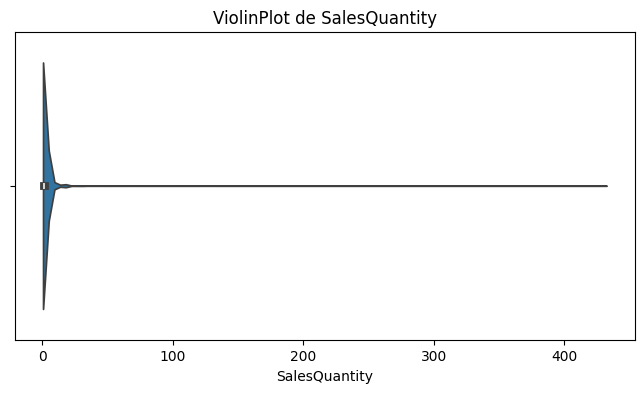

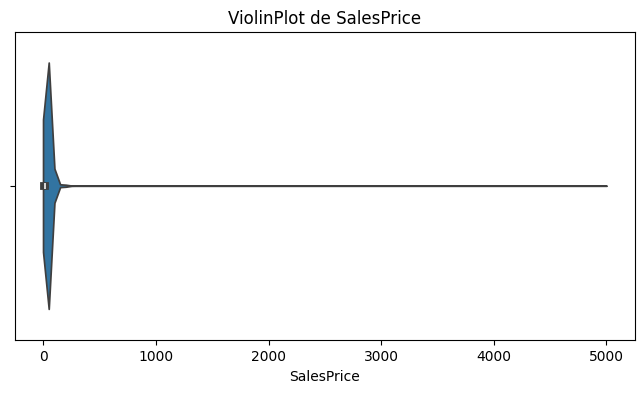

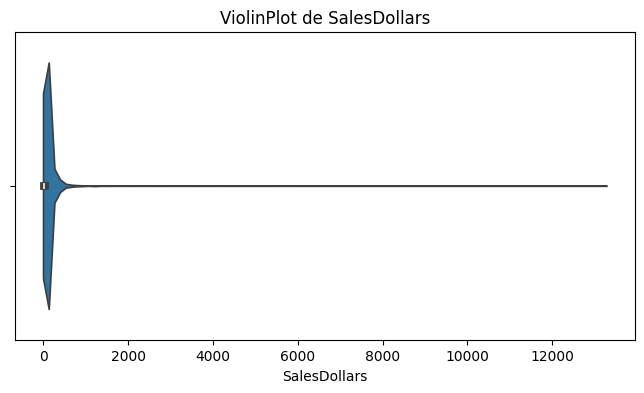

In [15]:
# lista de columnas numerica a analizar
numeric_cols = ['SalesQuantity','SalesPrice','SalesDollars']

for col in numeric_cols:
    plt.figure(figsize = (8 , 4) )
    sns.violinplot(x = df [col] )
    plt.title(f"ViolinPlot de {col}" )
    plt.show()

In [16]:
# Revisar valores negativos
for col in numeric_cols:
    neg_values = df [df [col] < 0 ]
    print (f"Valores negativos en {col}: {len (neg_values) } filas")

Valores negativos en SalesQuantity: 0 filas
Valores negativos en SalesPrice: 0 filas
Valores negativos en SalesDollars: 0 filas


## EDA Paso 7: Relaciones iniciales

* Correlación entre variables numéricas (df.corr()).

* Tablas de frecuencia para variables categóricas (value_counts()).

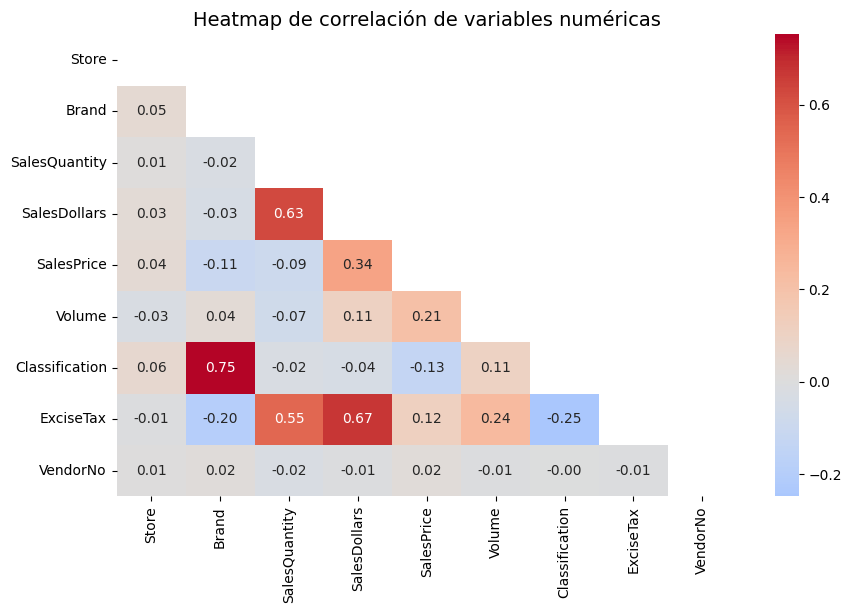

In [17]:
# Calculamos la matriz de correlación (solo numéricas)
corr_matrix = df.corr(numeric_only=True)

# Crear una máscara para el triángulo superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Ajustar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Heatmap
sns.heatmap(
    corr_matrix,        # matriz
    mask=mask,           
    annot=True,         # muestra los valores en cada celda
    fmt=".2f",          # formato de los números
    cmap="coolwarm",    # paleta de colores
    center=0            # centra el gradiente en 0
)

plt.title("Heatmap de correlación de variables numéricas", fontsize=14)
plt.show()

In [18]:
# Columnas categóricas
categorical_cols = df.select_dtypes(include=['object'])

# Mostrar las 5 categorías más frecuentes de cada columna
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(5))



--- InventoryId ---
InventoryId
13_TARMSWORTH_8064    57
13_TARMSWORTH_1892    56
14_BROMWICH_8910      56
13_TARMSWORTH_3837    56
10_HORNSEY_8184       56
Name: count, dtype: int64

--- Description ---
Description
Smirnoff 80 Proof          7123
Capt Morgan Spiced Rum     7057
Jack Daniels No 7 Black    7014
Jagermeister Liqueur       6763
Kahlua                     6527
Name: count, dtype: int64

--- Size ---
Size
750mL    593098
1.75L    172222
50mL     101816
1.5L      67189
375mL     52659
Name: count, dtype: int64

--- VendorName ---
VendorName
DIAGEO NORTH AMERICA INC       125869
JIM BEAM BRANDS COMPANY         94057
MARTIGNETTI COMPANIES           76251
CONSTELLATION BRANDS INC        70792
E & J GALLO WINERY              65240
Name: count, dtype: int64


* InventoryId

Los IDs más frecuentes corresponden a ciertas combinaciones de tienda y producto, por ejemplo 13_TARMSWORTH_8064 con 57 registros.

* Description

Productos más vendidos: Smirnoff 80 Proof (7123), Capt Morgan Spiced Rum (7057), etc.

* Size

Los tamaños predominantes son 750mL (593098), 1.75L (172222), 50mL (101816).

* VendorName

Los proveedores más frecuentes son DIAGEO NORTH AMERICA INC (125869), JIM BEAM BRANDS COMPANY (94057), etc.



## Normalizamos el texto dentro de las columnas que lo contienen
Vamos a pasarlo todo a minusculas y quitarles los espacios.

In [19]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.lower().str.strip().str.replace(" ", "_")



In [20]:
df.head()

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_hardersfield_1004,1,1004,jim_beam_w/2_rocks_glasses,750ml,1,16.49,16.49,2016-01-01,750,1,0.79,12546,jim_beam_brands_company
1,1_hardersfield_1004,1,1004,jim_beam_w/2_rocks_glasses,750ml,2,32.98,16.49,2016-01-02,750,1,1.57,12546,jim_beam_brands_company
2,1_hardersfield_1004,1,1004,jim_beam_w/2_rocks_glasses,750ml,1,16.49,16.49,2016-01-03,750,1,0.79,12546,jim_beam_brands_company
3,1_hardersfield_1004,1,1004,jim_beam_w/2_rocks_glasses,750ml,1,14.49,14.49,2016-01-08,750,1,0.79,12546,jim_beam_brands_company
4,1_hardersfield_1005,1,1005,maker's_mark_combo_pack,375ml_2_pk,2,69.98,34.99,2016-01-09,375,1,0.79,12546,jim_beam_brands_company


## Validacion de regla de negocio
Vamos a corroborar que el precio por unidad multiplicado por la cantidad sea igual al monto que figura en la columna Dollars

In [21]:
#Creamos una columna auxiliar para verificarlo

df["CalcDollars"] = df["salesprice"] * df["salesquantity"]

KeyError: 'salesprice'

In [ ]:
#Ahora calculamos la diferencia entre la columna calculada y la columna original (Dollars)

diff = (df["salesdollars"] - df["CalcDollars"]).abs().sum()
print("Diferencia total en Dollars:", diff)

Diferencia total en Dollars: 3.8490455267492507e-10


Podemos observar que la diferencia entre el calculo que hicimos y la tabla ya existente es practicamente nula.

In [ ]:
# Eliminamos la columna auxiliar
df.drop(columns=["CalcDollars"], inplace=True)

## Exportamos a BigQuery


In [ ]:
from google.cloud import bigquery

client = bigquery.Client()

table_id = "inventarioproject_henry.ventas_2017_clean"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",  # sobreescribe si ya existe
)

job = client.load_table_from_dataframe(df, table_id, job_config=job_config)
job.result()  # espera a que termine

print("Carga completada en BigQuery:", table_id)

c:\Users\Usuario\OneDrive\Escritorio\InventarioProject\PF-Inventory\venv_inventario\Lib\site-packages\google\cloud\bigquery\_pandas_helpers.py:484: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Carga completada en BigQuery: inventarioproject_henry.ventas_2017_clean
